In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [55]:
# Make data reproducible
np.random.seed(0)

# Generate X
X = np.linspace(-3, 3, 30).reshape(-1, 1)

# True function (simple curve)
y = 0.5 * X**2 + X + 2 + np.random.randn(30, 1)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [57]:
poly = PolynomialFeatures(degree=15)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)
print("Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Training MSE: 0.19879777491127604
Test MSE: 24122.849519293013


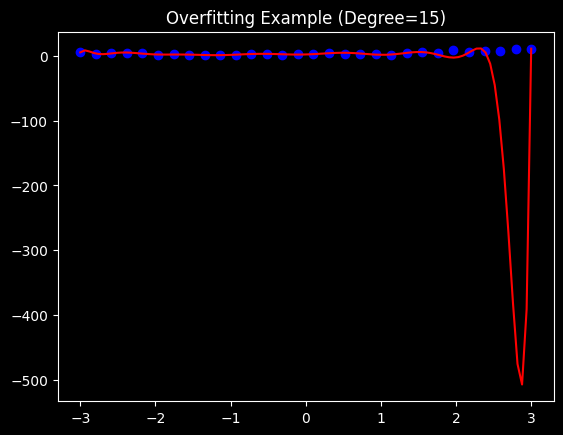

In [59]:
X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model.predict(X_plot_poly)

plt.scatter(X, y, color="blue")
plt.plot(X_plot, y_plot, color="red")
plt.title("Overfitting Example (Degree=15)")
plt.show()

Want to Fix It?

Training MSE: 1.0922547898194814
Test MSE: 0.925248252820064


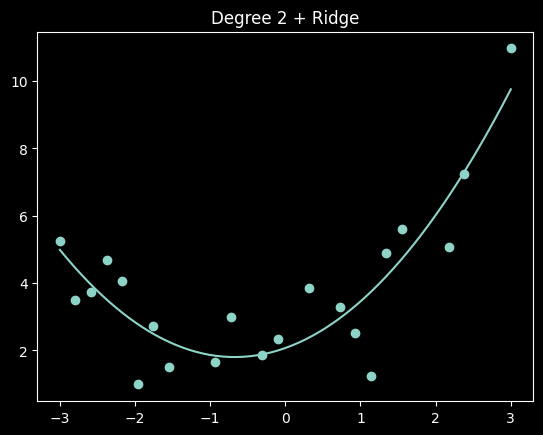

In [61]:
# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Ridge model (L2 regularization)
model = Ridge(alpha=1.0)
model.fit(X_train_poly, y_train)

# Predictions
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# Evaluate
print("Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)   # ← transform first
y_plot = model.predict(X_plot_poly)

plt.scatter(X_train, y_train)
plt.plot(X_plot, y_plot)
plt.title("Degree 2 + Ridge")
plt.show()


Best alpha: 0.01
Training MSE: 151.66844888762208
Test MSE: 27.373239331853746


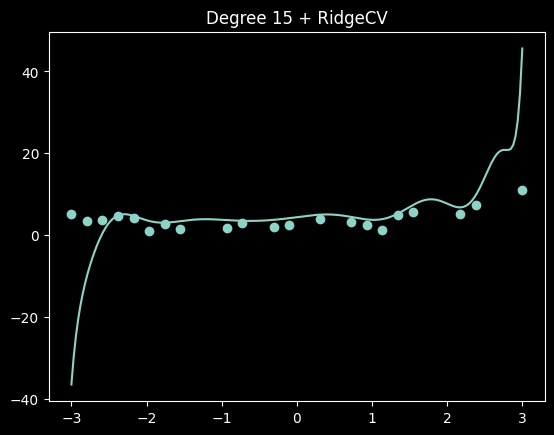

In [64]:
model = make_pipeline(
    PolynomialFeatures(degree=15),
    #RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
    RidgeCV(alphas=[0.01])
)

model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Best alpha:", model.named_steps['ridgecv'].alpha_)

# Evaluate
print("Training MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))


X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_plot = model.predict(X_plot)

plt.scatter(X_train, y_train)
plt.plot(X_plot, y_plot)
plt.title("Degree 15 + RidgeCV")
plt.show()